<a href="https://colab.research.google.com/github/Sakshi-coder1/workco/blob/main/DAY_4_(NLP_with_Python).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_excel("imdb_top_1000.xlsx")

In [5]:
print(df.head())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

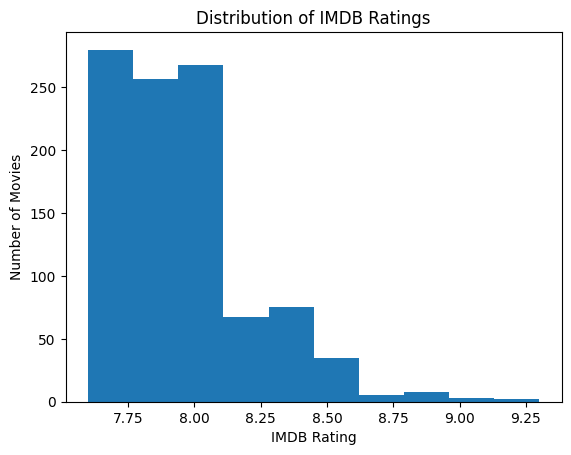

In [6]:
# Imdb rating didtribution
plt.hist(df['IMDB_Rating'],bins=10)
plt.title("Distribution of IMDB Ratings")
plt.xlabel("IMDB Rating")
plt.ylabel("Number of Movies")
plt.show()


In [7]:
# Top 10 movie genres
df['Genre']=df['Genre'].str.split(',').str[0]
genre_counts=df['Genre'].value_counts().head(10)

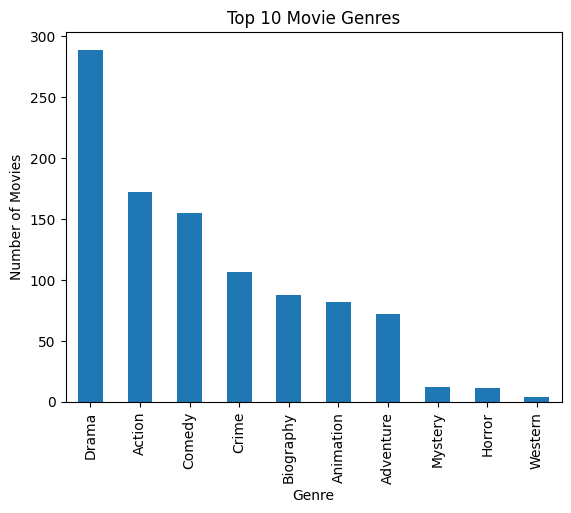

In [8]:
genre_counts.plot(kind='bar')
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()

In [10]:
# Average Rating by genre
average_rating=df.groupby("Genre")["IMDB_Rating"].mean()

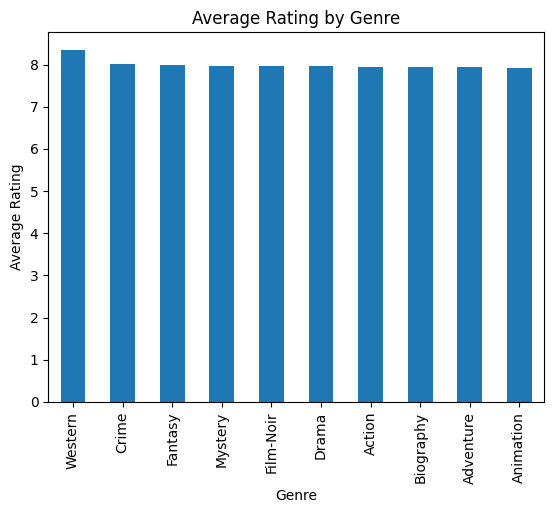

In [11]:
average_rating=average_rating.sort_values(ascending=False).head(10)
average_rating.plot(kind='bar')
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()

In [12]:
text=df['Overview'].dropna()

In [13]:
all_text=" ".join(text)

In [14]:
all_text=all_text.lower()

In [15]:
print(all_text)

two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency. an organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son. when the menace known as the joker wreaks havoc and chaos on the people of gotham, batman must accept one of the greatest psychological and physical tests of his ability to fight injustice. the early life and career of vito corleone in 1920s new york city is portrayed, while his son, michael, expands and tightens his grip on the family crime syndicate. a jury holdout attempts to prevent a miscarriage of justice by forcing his colleagues to reconsider the evidence. gandalf and aragorn lead the world of men against sauron's army to draw his gaze from frodo and sam as they approach mount doom with the one ring. the lives of two mob hitmen, a boxer, a gangster and his wife, and a pair of diner bandits intertwine in four tales of violence and redemption. in german-

In [16]:
import re
all_text=re.sub(r"[^A-Za-z0-9\s]","",all_text)

In [17]:
words=all_text.split()

In [18]:
!pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
filtered_words=[]
for word in words:
    if word not in stop_words:
        filtered_words.append(word)

In [20]:
from collections import Counter
word_counts=Counter(filtered_words)

In [21]:
# Word Frequency
top_words=word_counts.most_common(10)
print(top_words)

[('young', 132), ('man', 109), ('two', 104), ('life', 101), ('world', 78), ('new', 72), ('story', 63), ('war', 61), ('love', 61), ('woman', 60)]


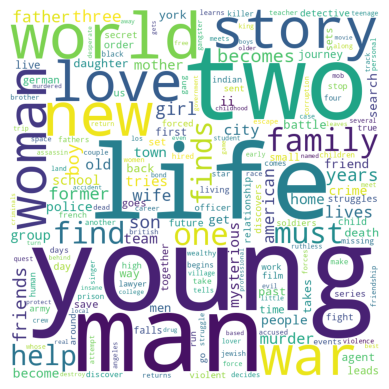

In [22]:
# Word Cloud
!pip install wordcloud
from wordcloud import WordCloud
wordcloud=WordCloud(width=800,height=800,background_color="white").generate_from_frequencies(word_counts)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()